Import all libraries

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import torch
from tqdm import tqdm
import time
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,log_loss,jaccard_score,roc_auc_score,classification_report,confusion_matrix
from torch.utils.data import Dataset, DataLoader
!pip install emoji
import emoji
import re
from sklearn.preprocessing import LabelEncoder

Read datasets

In [6]:
train_data = pd.read_csv('train.csv')
val_data = pd.read_csv('validation.csv')
test_data = pd.read_csv('test.csv')

Visualization of Label Distribution in Train Dataset

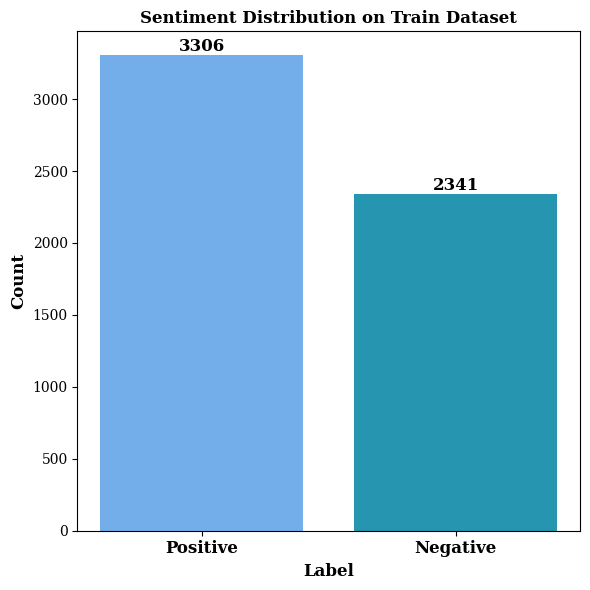

In [3]:
label_counts = train_data['sentiment'].value_counts()

# Define custom colors for the bars
custom_colors = ['#73aeea', '#2595b0']

# Define custom font dictionary for title and labels
font = {'family': 'Serif', 'weight': 'bold', 'size': 12}

plt.figure(figsize=(6, 6))

# Create bar plot with grid
bars = plt.bar(label_counts.index, label_counts.values, color=custom_colors)

# Set title and axis labels using custom fontdict
plt.title('Sentiment Distribution on Train Dataset', fontdict=font)
plt.xlabel('Label', fontdict=font)
plt.ylabel('Count', fontdict=font)

# Set custom font for ticks on both x and y axes
plt.xticks(label_counts.index, label_counts.index, fontdict=font)
plt.yticks(fontname='Serif', fontsize=10)

# Adding annotations (count values) on top of each bar
for bar, count in zip(bars, label_counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(count),
             ha='center', va='bottom', fontdict=font)

plt.show()

Visualization of Label Distribution in Validation Dataset

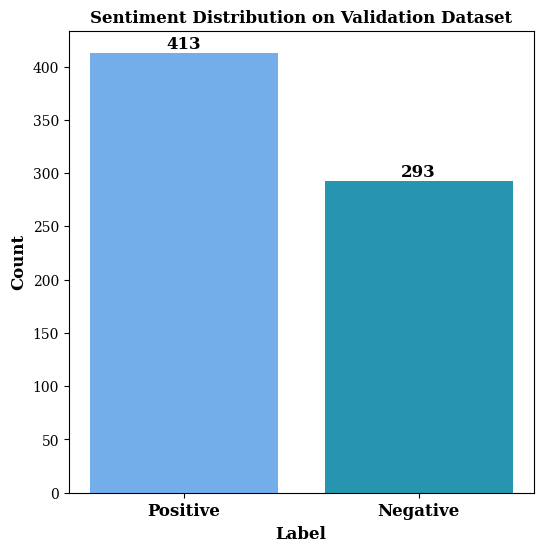

In [5]:
label_counts = val_data['sentiment'].value_counts()

# Define custom colors for the bars
custom_colors = ['#73aeea', '#2595b0']

# Define custom font dictionary for title and labels
font = {'family': 'Serif', 'weight': 'bold', 'size': 12}

plt.figure(figsize=(6, 6))

# Create bar plot with grid
bars = plt.bar(label_counts.index, label_counts.values, color=custom_colors)

# Set title and axis labels using custom fontdict
plt.title('Sentiment Distribution on Validation Dataset', fontdict=font)
plt.xlabel('Label', fontdict=font)
plt.ylabel('Count', fontdict=font)

# Set custom font for ticks on both x and y axes
plt.xticks(label_counts.index, label_counts.index, fontdict=font)
plt.yticks(fontname='Serif', fontsize=10)

# Adding annotations (count values) on top of each bar
for bar, count in zip(bars, label_counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(count),
             ha='center', va='bottom', fontdict=font)

plt.show()

Visualization of Label Distribution in Test Dataset

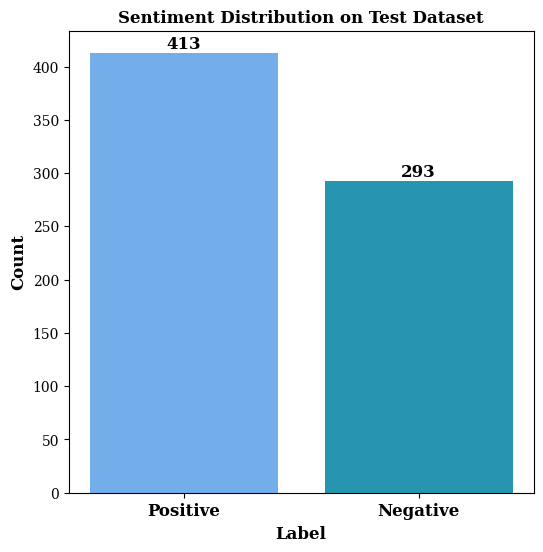

In [8]:
label_counts = test_data['sentiment'].value_counts()

# Define custom colors for the bars
custom_colors = ['#73aeea', '#2595b0']

# Define custom font dictionary for title and labels
font = {'family': 'Serif', 'weight': 'bold', 'size': 12}

plt.figure(figsize=(6, 6))

# Create bar plot with grid
bars = plt.bar(label_counts.index, label_counts.values, color=custom_colors)

# Set title and axis labels using custom fontdict
plt.title('Sentiment Distribution on Test Dataset', fontdict=font)
plt.xlabel('Label', fontdict=font)
plt.ylabel('Count', fontdict=font)

# Set custom font for ticks on both x and y axes
plt.xticks(label_counts.index, label_counts.index, fontdict=font)
plt.yticks(fontname='Serif', fontsize=10)

# Adding annotations (count values) on top of each bar
for bar, count in zip(bars, label_counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(count),
             ha='center', va='bottom', fontdict=font)

plt.show()

Preprocess the dataset

In [11]:
# 1. TEXT CLEANING FUNCTION
def clean_text(text):
    text = str(text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # Remove mentions
    text = re.sub(r'@\w+', '', text)

    # Remove hashtag symbol only
    text = re.sub(r'#', '', text)

    # Remove emojis
    text = emoji.replace_emoji(text, replace='')

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text


# 2. DROP MISSING VALUES
train_data = train_data.dropna(subset=["short_description", "sentiment"])
val_data = val_data.dropna(subset=["short_description", "sentiment"])
test_data = test_data.dropna(subset=["short_description", "sentiment"])


# 3. KEEP ONLY POSITIVE & NEGATIVE
train_data = train_data[train_data["sentiment"].isin(["Positive", "Negative"])]
val_data = val_data[val_data["sentiment"].isin(["Positive", "Negative"])]
test_data = test_data[test_data["sentiment"].isin(["Positive", "Negative"])]


# 4. MAP LABELS
label_map = {
    "Negative": 0,
    "Positive": 1
}

train_data["sentiment"] = train_data["sentiment"].map(label_map)
val_data["sentiment"] = val_data["sentiment"].map(label_map)
test_data["sentiment"] = test_data["sentiment"].map(label_map)


# 5. CLEAN TEXT
train_data["short_description"] = train_data["short_description"].apply(clean_text)
val_data["short_description"] = val_data["short_description"].apply(clean_text)
test_data["short_description"] = test_data["short_description"].apply(clean_text)


# 6. RESET INDEX
train_data = train_data.reset_index(drop=True)
val_data = val_data.reset_index(drop=True)
test_data = test_data.reset_index(drop=True)


# 7. SAVE CLEANED FILES
train_data.to_csv("train_clean.csv", index=False)
val_data.to_csv("validation_clean.csv", index=False)
test_data.to_csv("test_clean.csv", index=False)

print("Binary preprocessing completed successfully!")

Binary preprocessing completed successfully!
